# Chapitre 6 — Demande individuelle et fonctions de demande

## Question du chapitre

Une fois l'optimum de consommation trouvé, comment décrire la quantité choisie quand les prix ou le revenu changent ?

## Idée à comprendre d'abord

Jusqu'au chapitre 5, on cherchait l'optimum de consommation pour un revenu et des prix donnés. Ici, on change de question : on ne veut plus seulement **un panier de consommation optimal**, mais la **règle** qui donne ce panier quand $p_1$, $p_2$ ou $R$ changent. Cette règle, c'est la **fonction de demande**.

## 6.1. Fonctions de demande

Pour le bien 1 :

$$
x_1^*=D_1(p_1,p_2,R)
$$

Pour le bien 2 :

$$
x_2^*=D_2(p_1,p_2,R)
$$

**À retenir** : une fonction de demande n'est pas une intention vague ; c'est une règle qui associe à chaque environnement de prix et de revenu une quantité choisie.

Autrement dit, $x_1^*$ et $x_2^*$ sont les composantes du panier de consommation optimal associé à des prix $(p_1,p_2)$ et un revenu $R$ donnés. La nouveauté du chapitre 6 est qu'on les étudie comme des fonctions de ces variables : par exemple, quand $p_1$ varie, à $p_2$ et $R$ fixés, on observe comment $x_1^*$ et $x_2^*$ changent, et non plus seulement un optimum de consommation isolé.

## 6.2. Courbe de demande

La courbe de demande relie le prix d'un bien à la quantité demandée, toutes choses égales par ailleurs.

En général :

$$
\frac{\partial D_1}{\partial p_1}<0
$$

Autrement dit, une hausse du prix tend à réduire la quantité demandée.

## 6.3. Courbe prix-consommation

Quand le prix d'un bien varie, à revenu et prix de l'autre bien constants, l'optimum de consommation se déplace. La courbe qui relie ces optimums de consommation successifs est la **courbe prix-consommation**.

**Attention** : cette courbe n'est pas tracée dans un repère prix-quantité, mais dans le plan des paniers $(x_1,x_2)$. Ici, c'est $p_1$ qui varie, et chaque point de la courbe représente un panier optimal $(x_1^*,x_2^*)$.

Le graphique ajouté ci-dessous illustre ce déplacement quand le prix du bien 1 varie, à revenu et prix du bien 2 constants.

Elle sert de pont entre l'analyse graphique du consommateur et la construction de la courbe de demande.

## 6.4. Courbe revenu-consommation

Quand le revenu varie à prix constants, les droites de budget se déplacent parallèlement. Les optimums de consommation successifs forment la **courbe revenu-consommation**.

Cette courbe permet de voir si un bien devient plus ou moins demandé quand le revenu augmente.

## 6.5. Courbe d'Engel

La courbe d'Engel relie directement le revenu à la quantité demandée d'un bien.

- pente positive : bien normal ;
- pente négative : bien inférieur ;
- pente très forte : bien de luxe possible.

## Méthode de lecture

Quand un exercice parle de demande, demande-toi toujours :

1. qu'est-ce qui varie : prix ou revenu ?
2. est-ce qu'on lit une demande, une courbe prix-consommation ou une courbe d'Engel ?
3. quel type de bien cela suggère-t-il ?

## Erreur classique

Confondre la **courbe de demande** avec la **courbe d'Engel**. La première relie quantité et prix ; la seconde relie quantité et revenu.

---

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

FIG_DIR = Path("microeco_v5_figures")
FIG_DIR.mkdir(exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 160,
    "savefig.dpi": 200,
    "font.size": 11
})

def save_fig(name):
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"{name}.png", bbox_inches="tight")
    plt.savefig(FIG_DIR / f"{name}.svg", bbox_inches="tight")
    plt.show()


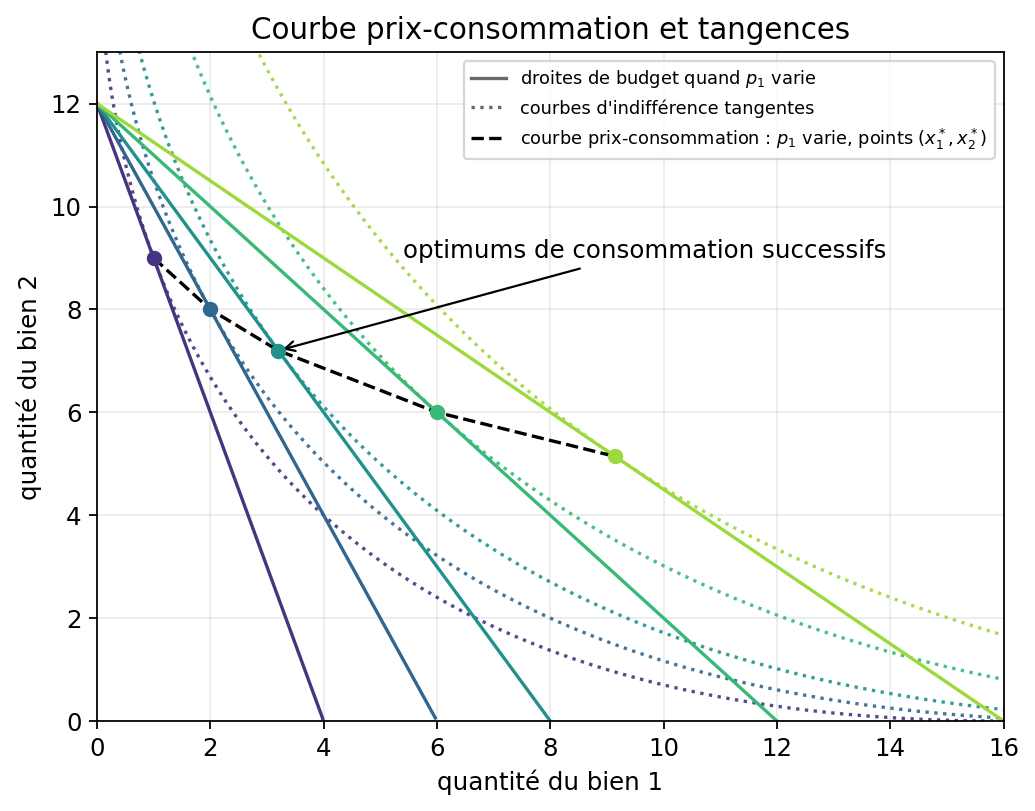

In [ ]:
# 13 courbe prix-consommation
R = 12
p2 = 1
p1_values = [3, 2, 1.5, 1, 0.75]
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(p1_values)))
x = np.linspace(0.01, 16, 500)

plt.figure(figsize=(6.6, 5.2))

opt_points_x = []
opt_points_y = []

for p1, color in zip(p1_values, colors):
    y_budget = (R - p1 * x) / p2
    mask_budget = y_budget >= 0
    plt.plot(x[mask_budget], y_budget[mask_budget], color=color)

    # Fonction illustrative : U(x_1,x_2)=\sqrt{x_1}+\sqrt{x_2}
    x1_star = R / (p1 * (p1 + p2))
    x2_star = R * p1 / (p1 + p2)
    opt_points_x.append(x1_star)
    opt_points_y.append(x2_star)

    utility_star = np.sqrt(x1_star) + np.sqrt(x2_star)
    y_indiff = (utility_star - np.sqrt(x)) ** 2
    mask_indiff = (utility_star - np.sqrt(x)) >= 0
    plt.plot(
        x[mask_indiff],
        y_indiff[mask_indiff],
        color=color,
        linestyle=':',
        alpha=0.9
    )

    plt.scatter([x1_star], [x2_star], color=color, s=35, zorder=4)

plt.plot(
    opt_points_x,
    opt_points_y,
    color='black',
    linestyle='--',
    linewidth=1.5,
    label='_nolegend_'
 )
plt.annotate(
    'optimums de consommation successifs',
    xy=(opt_points_x[2], opt_points_y[2]),
    xytext=(5.4, 9.0),
    arrowprops=dict(arrowstyle='->', color='black')
)

plt.plot([], [], color='dimgray', linestyle='-', label="droites de budget quand $p_1$ varie")
plt.plot([], [], color='dimgray', linestyle=':', label="courbes d'indifférence tangentes")
plt.plot([], [], color='black', linestyle='--', linewidth=1.5, label="courbe prix-consommation : $p_1$ varie, points $(x_1^*,x_2^*)$")

plt.xlim(0, 16)
plt.ylim(0, 13)
plt.xlabel('quantité du bien 1')
plt.ylabel('quantité du bien 2')
plt.title('Courbe prix-consommation et tangences\n$U(x_1,x_2)=\sqrt{x_1}+\sqrt{x_2}$')
plt.grid(True, alpha=.25)
plt.legend(loc='best', fontsize=8)
save_fig('13_courbe_prix_consommation')